# Классификация. Логистическая регрессия


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Задача:

https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [2]:
df = pd.read_csv('loan_data.csv', sep=',')#, index_col=0)
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


In [3]:
df.shape

(45000, 14)

In [4]:
df["loan_status"].unique() # - бинарная классификация

array([1, 0])

## Обработка категориальных признаков

### LabelEncoder

In [5]:
df.select_dtypes(include=['object']).columns

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [6]:
df[['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']].head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [7]:
from sklearn.preprocessing import LabelEncoder
lab_encoder = LabelEncoder()
df["person_gender"] = lab_encoder.fit_transform(df["person_gender"])
df["previous_loan_defaults_on_file"]=lab_encoder.fit_transform(df["previous_loan_defaults_on_file"])
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,1,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [8]:
df["person_education"].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

<Axes: xlabel='person_education', ylabel='Count'>

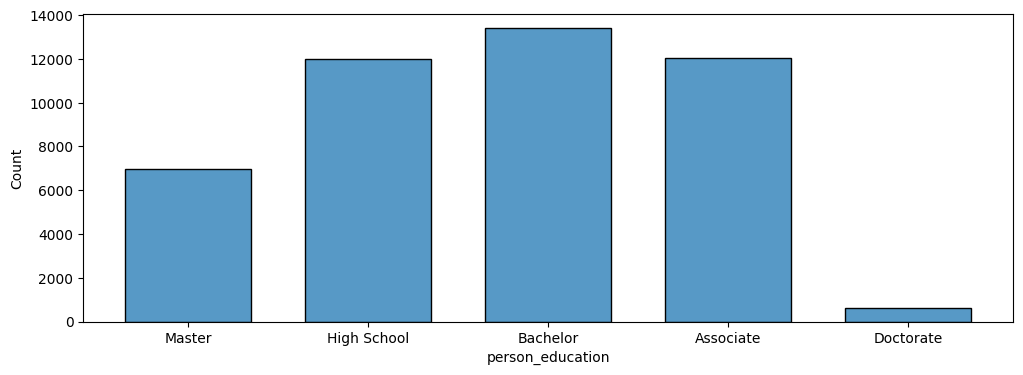

In [9]:
plt.figure(figsize=(12, 4))
sns.histplot(df['person_education'], shrink=0.7)

In [10]:
# всегда можно закодировать вручную
map_dict = {'High School' : 1,
            'Associate' : 4,
            'Bachelor': 9,
            'Master' : 16,
            'Doctorate' : 25}

df['person_education_num'] = df['person_education'].map(map_dict)
df[['person_gender', 'person_education', 'person_education_num']].head()

,person_gender,person_education,person_education_num
0,0,Master,16
1,0,High School,1
2,0,High School,1
3,0,Bachelor,9
4,1,Master,16


In [11]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']])

df["person_education_num"] = ord_encoder.fit_transform(df[["person_education"]])
df[['person_gender', 'person_education', 'person_education_num']].head()

,person_gender,person_education,person_education_num
0,0,Master,3.0
1,0,High School,0.0
2,0,High School,0.0
3,0,Bachelor,2.0
4,1,Master,3.0


### OnehotEncoder

<Axes: xlabel='person_home_ownership', ylabel='Count'>

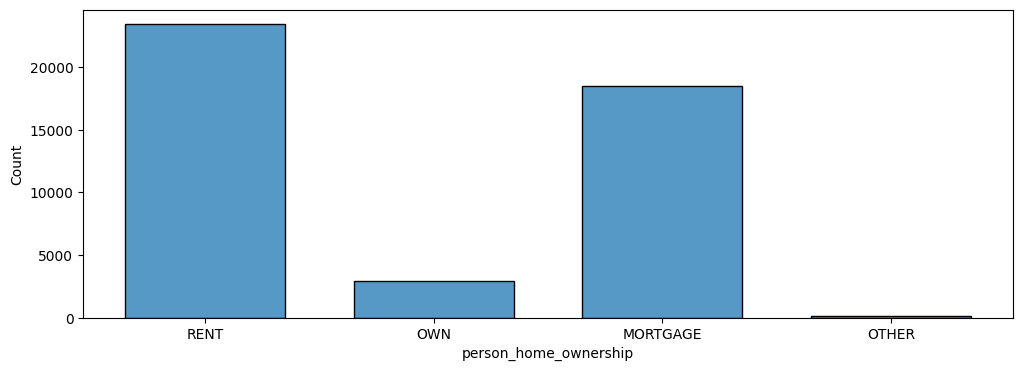

In [12]:
plt.figure(figsize=(12, 4))
sns.histplot(df['person_home_ownership'], shrink=0.7)

In [13]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder()
encode = onehot.fit_transform(df[['person_home_ownership']])

In [14]:
df_encoded = pd.DataFrame(encode.toarray(), columns=onehot.categories_[0])
df_encoded.head()

# можно onehot.get_feature_names_out()

,MORTGAGE,OTHER,OWN,RENT
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0


In [15]:
df_encoded = df_encoded.drop('OTHER', axis = 1) # можно удалить OTHER (почему?)

In [16]:
df = df.join(df_encoded)  # не путать с SQL-join, в pandas это merge
                          # join - функция для слияния таблиц по индексам
df.drop('person_home_ownership', axis = 1, inplace = True) # удаляем исходный признак

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_education_num,MORTGAGE,OWN,RENT
0,22.0,0,Master,71948.0,0,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1,3.0,0.0,0.0,1.0
1,21.0,0,High School,12282.0,0,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0,0.0,0.0,1.0,0.0
2,25.0,0,High School,12438.0,3,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1,0.0,1.0,0.0,0.0
3,23.0,0,Bachelor,79753.0,0,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1,2.0,0.0,0.0,1.0
4,24.0,1,Master,66135.0,1,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1,3.0,0.0,0.0,1.0


Главный недостаток One-Hot Encoder'a заключается в существенном увеличении объема данных

<Axes: xlabel='loan_intent', ylabel='Count'>

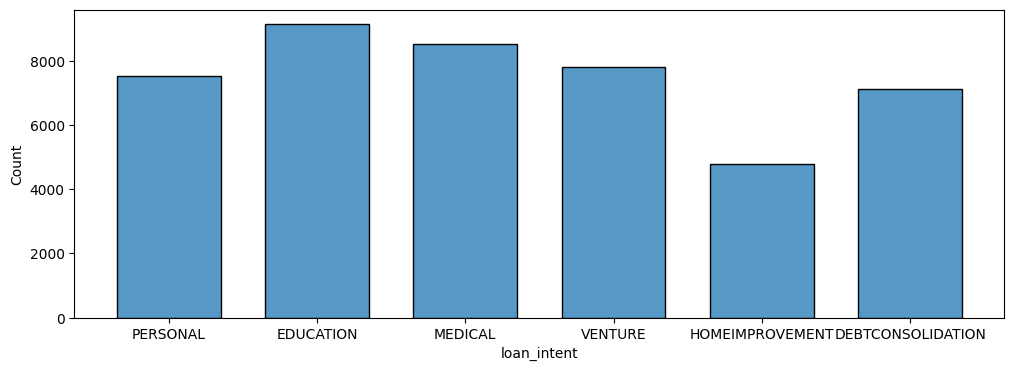

In [17]:
plt.figure(figsize=(12, 4))
sns.histplot(df['loan_intent'], shrink=0.7)

In [18]:
!pip install category_encoders

In [19]:
from category_encoders.binary import BinaryEncoder

b_encoder = BinaryEncoder()
b_encoded = b_encoder.fit_transform(df[['loan_intent']])
b_encoded.head()

,loan_intent_0,loan_intent_1,loan_intent_2
0,0,0,1
1,0,1,0
2,0,1,1
3,0,1,1
4,0,1,1


Недостаток - теряется интерпретируемость

<Axes: xlabel='loan_intent', ylabel='Count'>

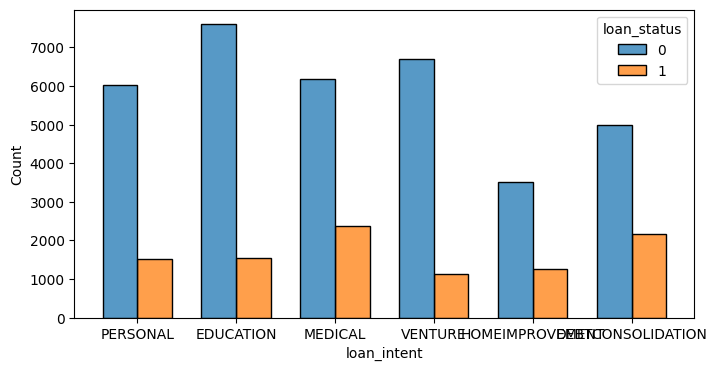

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df, x="loan_intent", hue="loan_status", multiple="dodge", shrink=0.7)

Другая идея: использование целевой переменной

In [21]:
df.groupby(["loan_intent"]).agg({
  "loan_status": "mean"
}).reset_index()

,loan_intent,loan_status
0,DEBTCONSOLIDATION,0.302729
1,EDUCATION,0.169562
2,HOMEIMPROVEMENT,0.263015
3,MEDICAL,0.278194
4,PERSONAL,0.201404
5,VENTURE,0.144264


Есть нюансы применения:
* выборка среднего применяется на тренировочной выборке
* возможна утечка данных (т.к. буквально используется целевая переменная)
  * экстремальный пример - признак с одним объектом
  * поэтому используется KFold

In [22]:
toy_df = pd.DataFrame({
    "category": ["cat1"]*2+["cat2"]*3+["cat3"],
    "y": [0,1,0,1,0,1]
})
toy_df

,category,y
0,cat1,0
1,cat1,1
2,cat2,0
3,cat2,1
4,cat2,0
5,cat3,1


In [23]:
toy_df.groupby(["category"]).agg({
  "y": "mean"
}).reset_index()

,category,y
0,cat1,0.500000
1,cat2,0.333333
2,cat3,1.000000


In [24]:
#Target Encoder для задачи регрессии использует среднее значение целевой метки по данному значению
from sklearn.preprocessing import TargetEncoder

target_encoder = TargetEncoder(cv=5) #по умолчанию
target = target_encoder.fit_transform(df[['loan_intent']], df[['loan_status']])
target

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[0.19840843],
       [0.17050952],
       [0.27360938],
       ...,
       [0.3030717 ],
       [0.16796568],
       [0.30008731]])

In [25]:
t_encoder = TargetEncoder(cv=2)
toy_df['target'] = t_encoder.fit_transform(toy_df[['category']], toy_df['y'])
toy_df

,category,y,target
0,cat1,0,0.333333
1,cat1,1,0.333333
2,cat2,0,0.666667
3,cat2,1,0.666667
4,cat2,0,0.666667
5,cat3,1,0.333333


In [26]:
# Другая модификация метода - Leave-One-Out Encoder
# Кодирование среднего без учета значения данного объекта

from category_encoders import LeaveOneOutEncoder
loo_encoder = LeaveOneOutEncoder()

In [27]:
df.head(1)

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_education_num,MORTGAGE,OWN,RENT
0,22.0,0,Master,71948.0,0,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1,3.0,0.0,0.0,1.0


In [28]:
from sklearn.model_selection import train_test_split

X = df[['person_age', 'person_gender', 'person_education_num', 'person_income',
       'person_emp_exp', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'MORTGAGE', 'OWN', 'RENT']]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [29]:
# fit только на train-выборке

target_encoder = TargetEncoder()
target_encoder.fit(X_train[['loan_intent']], y_train)

X_train['loan_intent'] = target_encoder.transform(X_train[['loan_intent']])
X_test['loan_intent'] = target_encoder.transform(X_test[['loan_intent']])

In [30]:
X_train.head(3)

,person_age,person_gender,person_education_num,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,MORTGAGE,OWN,RENT
25180,34.0,0,2.0,97265.0,11,15000.0,0.201496,12.73,0.15,9.0,631,0,1.0,0.0,0.0
12555,25.0,1,0.0,72953.0,3,12000.0,0.142453,11.86,0.16,4.0,659,1,0.0,0.0,1.0
29153,41.0,0,3.0,322597.0,18,24000.0,0.201496,10.37,0.07,11.0,683,1,1.0,0.0,0.0


## Обучение базовой модели

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Логистическая регрессия:
* Хорошо работает, если зависимость между целевой переменной и признаками имеет линейный характер
* Хорошо интерпретируется
* Перед использованием лучше провести нормализацию данных, т.к масштаб влияет на веса


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)  # координатный спуск
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [32]:
y_pred = model.predict(X_test)

model.coef_

array([[-4.29076512e-02, -2.56921884e-03,  4.10686753e-03,
        -2.91132982e-05,  3.07487125e-02,  1.03079809e-04,
         6.53683855e-03,  3.00193564e-01,  6.80166272e-03,
         1.15197512e-02, -4.36385820e-03, -2.15272356e-01,
        -4.68932281e-02, -2.73147062e-02,  6.98367738e-02]])

## Оценка модели

Проверим результат. Воспользуемся метрикой Accuracy

In [33]:
from sklearn import metrics

# средняя абсолютная ошибка
print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
#print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.8286666666666667


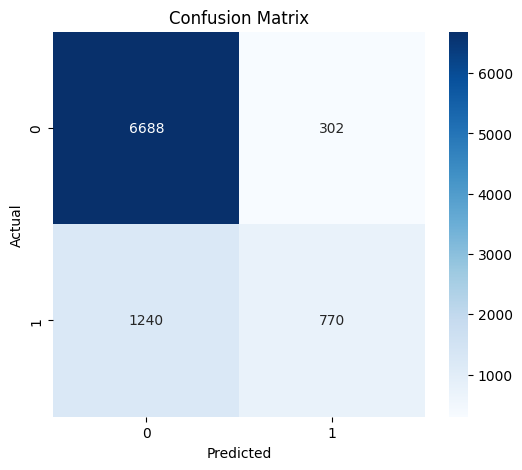

In [34]:
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Геометрический смысл

In [35]:
X = df[['person_age', 'person_income']]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
#print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.7766666666666666


In [36]:
X_train[:1]

,person_age,person_income
25180,34.0,97265.0


In [37]:
model.intercept_, model.coef_

(array([-0.13888942]), array([[ 2.71389974e-03, -1.70903724e-05]]))

In [38]:
model.intercept_ + model.coef_[0][0]*34 + model.coef_[0][1]*97265.0

array([-1.7089119])

In [39]:
1 / (1 + np.exp(-1.7089119))

np.float64(0.8466950994002495)

In [40]:
model.predict_proba(X_train[:1])

array([[0.8466951, 0.1533049]])

In [41]:
model.predict(X_train[:1])

array([0])

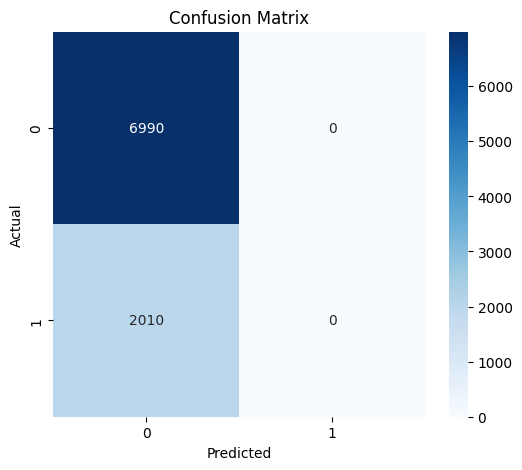

In [42]:
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))

Accuracy =  0.7766666666666666


# Улучшения

In [92]:
df = pd.read_csv('loan_data.csv', sep=',')#, index_col=0)
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


In [93]:
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
lab_encoder = LabelEncoder()

df["person_gender"] = lab_encoder.fit_transform(df["person_gender"])
df["previous_loan_defaults_on_file"] = lab_encoder.fit_transform(df["previous_loan_defaults_on_file"])
df[['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']].head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,0,Master,RENT,PERSONAL,0
1,0,High School,OWN,EDUCATION,1
2,0,High School,MORTGAGE,MEDICAL,0
3,0,Bachelor,RENT,MEDICAL,0
4,1,Master,RENT,MEDICAL,0


In [94]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']])
df["person_education"] = ord_encoder.fit_transform(df[["person_education"]])

In [95]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder()
encode = onehot.fit_transform(df[['person_home_ownership']])
df_encoded = pd.DataFrame(encode.toarray(), columns=onehot.categories_[0])
df = df.join(df_encoded)
df.drop('person_home_ownership', axis = 1, inplace = True)
df = df.drop('OTHER', axis = 1)

In [96]:
onehot = OneHotEncoder()
encode = onehot.fit_transform(df[['loan_intent']])

df_encoded = pd.DataFrame(encode.toarray(), columns=onehot.categories_[0])
df = df.join(df_encoded)
df.drop('loan_intent', axis = 1, inplace = True)

In [97]:
df_encoded.head()

,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0


In [98]:
df.drop('loan_amnt', axis = 1, inplace = True) # loan_int_rate = loan_amnt/person_income

<Axes: xlabel='person_income'>

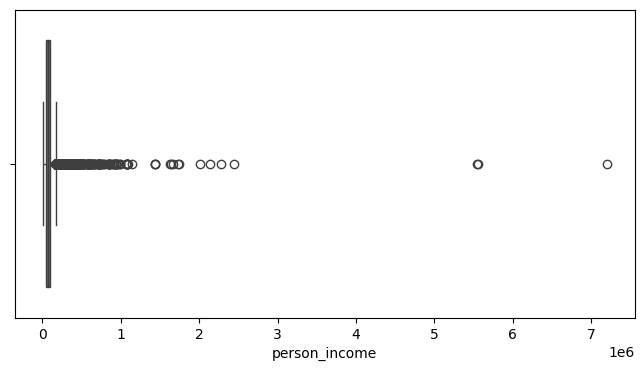

In [99]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['person_income'])

<Axes: xlabel='person_income', ylabel='Count'>

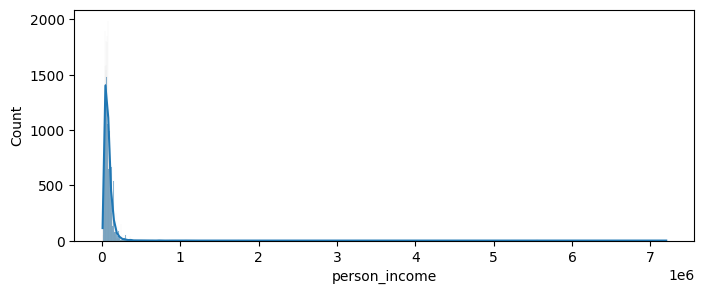

In [100]:
plt.figure(figsize=(8, 3))
sns.histplot(df, x="person_income", kde=True)

In [101]:
df.loc[:, 'person_income'] = df['person_income'].apply(np.log1p)

<Axes: xlabel='person_income', ylabel='Count'>

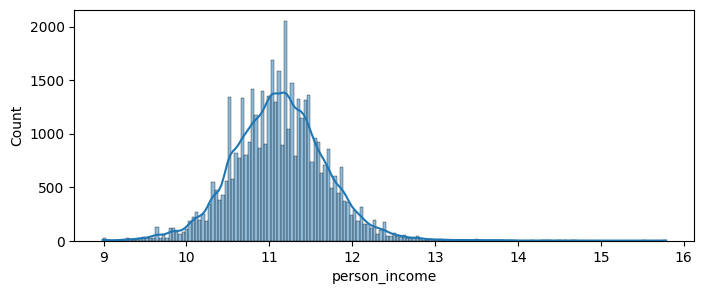

In [102]:
plt.figure(figsize=(8, 3))
sns.histplot(df, x="person_income", kde=True)

## Binning

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

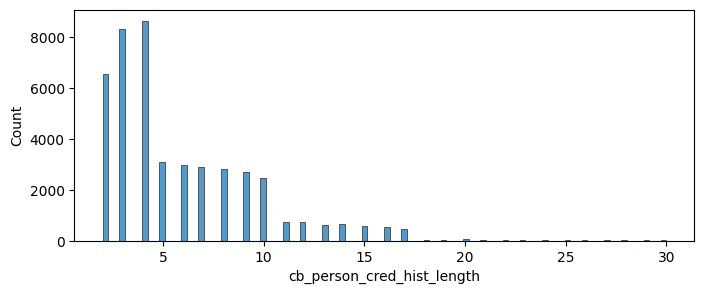

In [103]:
plt.figure(figsize=(8, 3))
sns.histplot(df, x="cb_person_cred_hist_length")

<Axes: xlabel='cred_hist', ylabel='Count'>

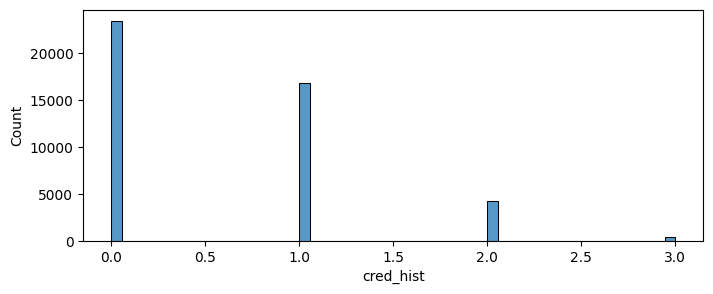

In [104]:
df.loc[df['cb_person_cred_hist_length'] >= 18, 'cred_hist'] = 3
df.loc[df['cb_person_cred_hist_length'] < 18, 'cred_hist'] = 2
df.loc[df['cb_person_cred_hist_length'] < 11, 'cred_hist'] = 1
df.loc[df['cb_person_cred_hist_length'] < 5, 'cred_hist'] = 0
df.drop('cb_person_cred_hist_length', axis = 1, inplace = True)

plt.figure(figsize=(8, 3))
sns.histplot(df, x="cred_hist")

<Axes: xlabel='person_age'>

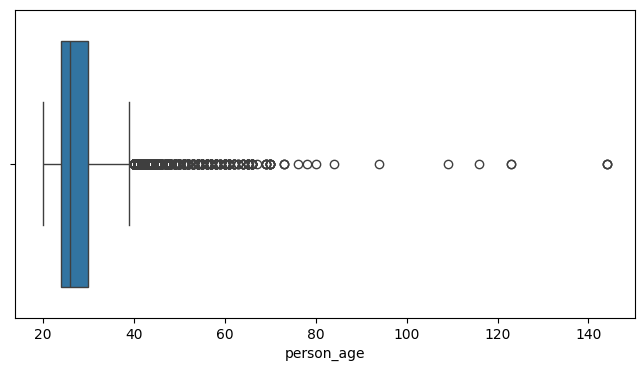

In [105]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['person_age'])

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('loan_status', axis = 1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

outliers = X_train[(X_train['person_income']>15) | (X_train['person_age']>100)].index
X_train = X_train.drop(outliers, axis=0)
y_train = y_train.drop(outliers)

In [116]:
model = LogisticRegression(penalty='l2', C=5.0, max_iter=200, solver='newton-cg', random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.8966666666666666
F1 =  0.7652700656234225


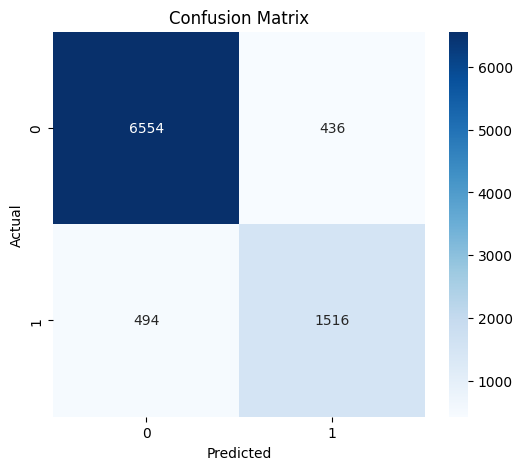

In [143]:
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [144]:
# фокус

df["loan_status"] = df["loan_status"].replace(0, 5)
df["loan_status"] = df["loan_status"].replace(1, 0)
df["loan_status"] = df["loan_status"].replace(5, 1)

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('loan_status', axis = 1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

outliers = X_train[(X_train['person_income']>15) | (X_train['person_age']>100)].index
X_train = X_train.drop(outliers, axis=0)
y_train = y_train.drop(outliers)

In [146]:
model = LogisticRegression(penalty='l2', C=5.0, max_iter=200, solver='newton-cg', random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.8963333333333333
F1 =  0.9335422750908184


<Axes: xlabel='loan_status', ylabel='Count'>

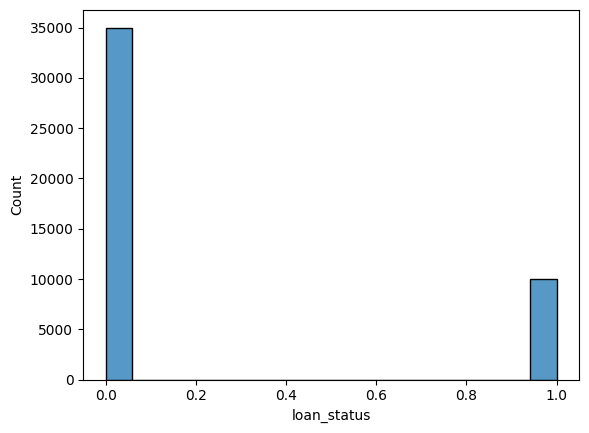

In [134]:
sns.histplot(df['loan_status'])

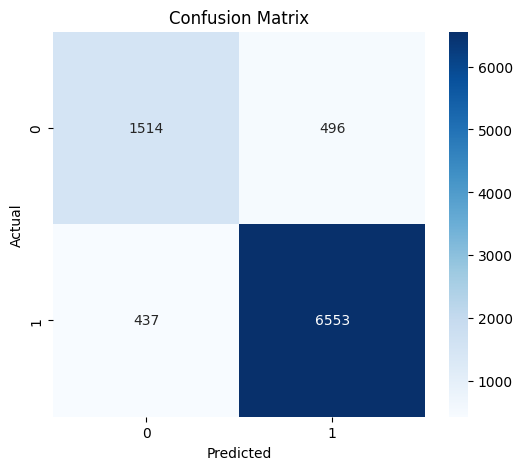

In [147]:
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Precision & Recall

Precision = TP/(TP+FP)

доля объектов, названных классификатором положительными от всех его положительных ответов

In [138]:
print('precision_score = ', metrics.precision_score(y_test, y_pred))
print('precision_score = ', 1516/(1516+436))

precision_score =  0.7766393442622951
precision_score =  0.7766393442622951


Recall = TP/(TP+FN)

доля объектов, названных классификатором положительными от всех объектов положительного класса

In [139]:
print('recall_score = ', metrics.recall_score(y_test, y_pred))
print('recall_score = ', 1516/(1516+494))

recall_score =  0.7542288557213931
recall_score =  0.7542288557213931


Баланс метрик - среднее гармоническое

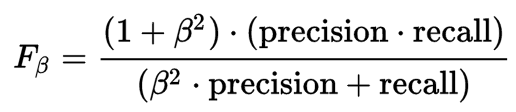

In [140]:
print('F1 = ', metrics.f1_score(y_test, y_pred))

F1 =  0.7652700656234225


## Кривая ROC и оценка AUC

Полнота и точность описывают производительность классификатора только при определенном пороге. Часто бывает полезно иметь метрику, которая оценивает производительность классификатора для всех возможных пороговых значений. Основана на двух величинах:

доля ложноположительных результатов

FPR = FP / (FP + TN)

доля истинно положительных результатов

TPR = TP / (TP + FN)

ROC-AUC =  0.8459270172741443


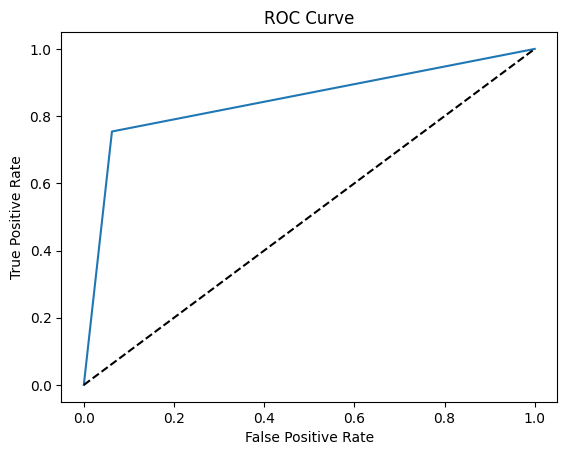

In [141]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

#вычисление ROC-AUC
auc_score = roc_auc_score(y_test, y_pred)
print('ROC-AUC = ', auc_score)

# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

ROC-AUC =  0.49573698033437963


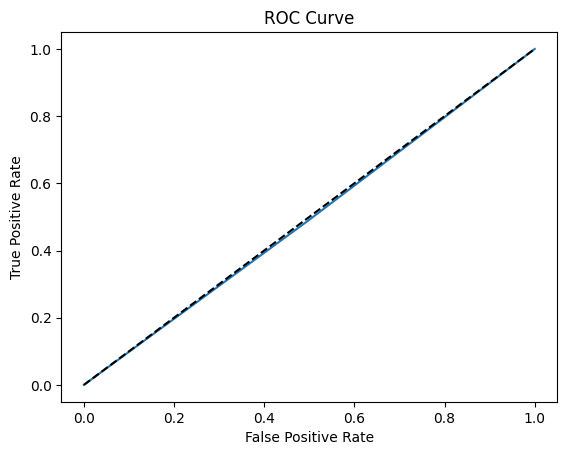

In [142]:
y_rand = np.random.choice([0,1],size=len(y_test))

#вычисление ROC-AUC
auc_score = roc_auc_score(y_test, y_rand)
print('ROC-AUC = ', auc_score)

# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_rand)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

Возвращаясь к вопросу о пороге:

In [151]:
proba = model.predict_proba(X_test)[:, 1]
threshold = 0.1
y_pred = (proba >= threshold).astype(int)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.8283333333333334
F1 =  0.9003290110315464


In [152]:
proba = model.predict_proba(X_test)[:, 1]
threshold = 0.7
y_pred = (proba >= threshold).astype(int)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
print('F1 = ', metrics.f1_score(y_test, y_pred))

Accuracy =  0.8764444444444445
F1 =  0.9168784571684856


### Не подбирать на тестовой выборке!

Порог это гиперпараметр, его нельзя выбирать на тестовой выборке, иначе будет утечка

In [154]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l2', C=5.0, max_iter=200, solver='newton-cg', random_state=42)

# Автоматический подбор порога по метрике
tuned = TunedThresholdClassifierCV(
    model,
    scoring="f1",
    cv=5
)

tuned.fit(X_train, y_train)
print("Подобранный порог:", tuned.best_threshold_)
y_pred = tuned.predict(X_test)

print('Accuracy = ', metrics.accuracy_score(y_test, y_pred))
print('F1 = ', metrics.f1_score(y_test, y_pred))

Подобранный порог: 0.4555766600301973
Accuracy =  0.8953333333333333
F1 =  0.9336058641105159
